In [2]:
import os
import shutil
import random
from tqdm import tqdm

import numpy as np
import pandas as pd

import PIL
import seaborn as sns
import matplotlib.pyplot as plt

DATASET = "../datasets/EuroSAT/2750"

LABELS = os.listdir(DATASET)
print(LABELS)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [3]:
counts = {}

for label in LABELS:
    label_dir = os.path.join(DATASET, label)
    counts[label] = len(os.listdir(label_dir))
print(counts)


{'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}


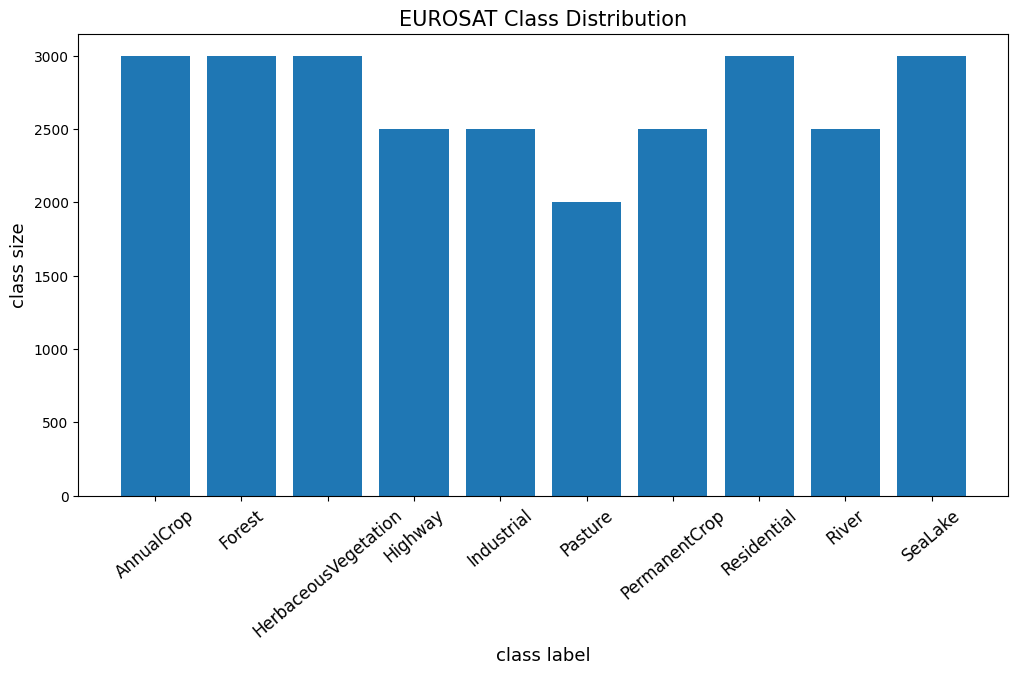

In [4]:
plt.figure(figsize=(12, 6))

plt.bar(range(len(counts)), list(counts.values()), align='center')
plt.xticks(range(len(counts)), list(counts.keys()), fontsize=12, rotation=40)
plt.xlabel('class label', fontsize=13)
plt.ylabel('class size', fontsize=13)
plt.title('EUROSAT Class Distribution', fontsize=15);

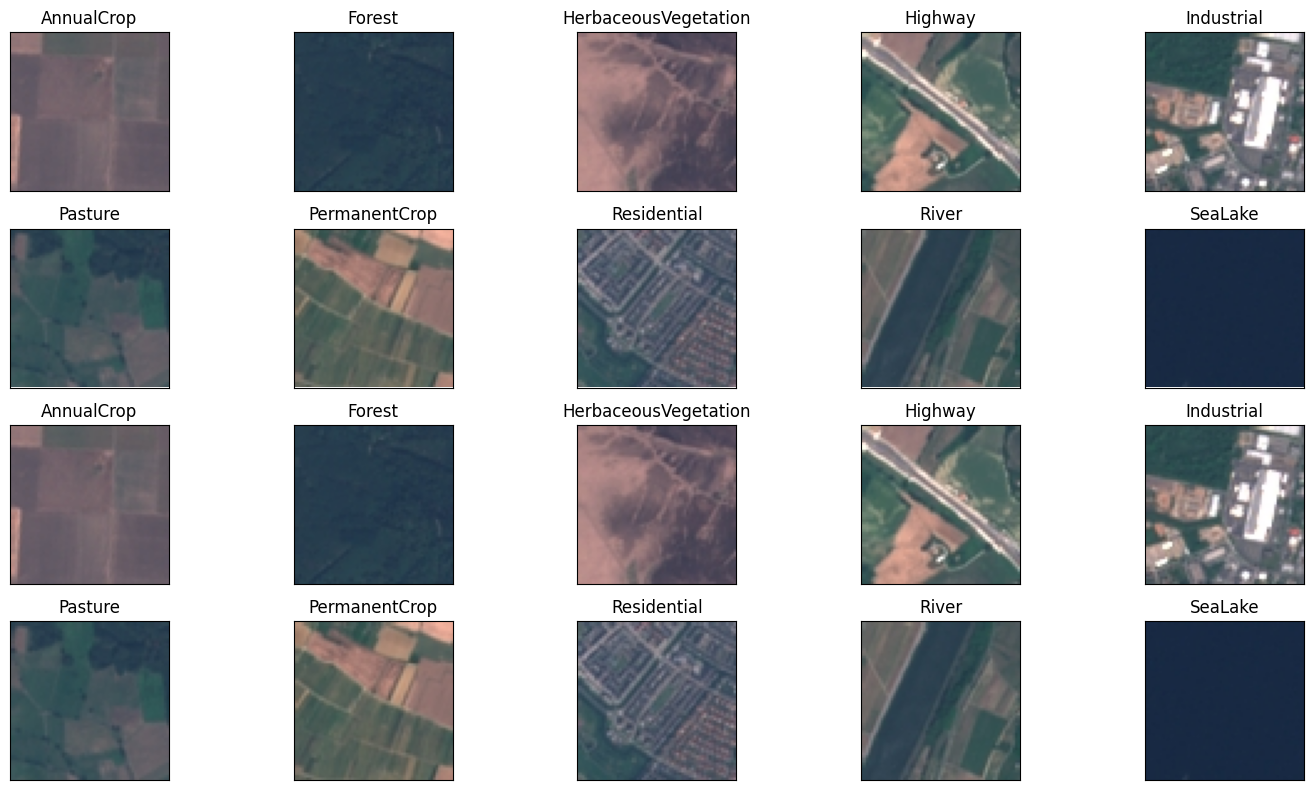

In [5]:
# Safe sample plotting: list actual files instead of assuming fixed names
import glob
img_paths = []
for l in LABELS:
    files = glob.glob(os.path.join(DATASET, l, '*'))
    files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
    if files:
        img_paths.append(files[0])

# repeat/pad until we have up to 20 images (or as many as available)
idx = 0
while len(img_paths) < 20 and idx < len(LABELS):
    l = LABELS[idx % len(LABELS)]
    files = glob.glob(os.path.join(DATASET, l, '*'))
    files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
    if files:
        img_paths.append(files[0])
    idx += 1

def plot_sat_imgs(paths):
    plt.figure(figsize=(15, 8))
    for i in range(min(20, len(paths))):
        plt.subplot(4, 5, i+1, xticks=[], yticks=[])
        try:
            img = PIL.Image.open(paths[i])
            plt.imshow(np.asarray(img))
            plt.title(os.path.basename(os.path.dirname(paths[i])))
        except Exception as e:
            plt.text(0.5, 0.5, 'error', horizontalalignment='center')
            plt.title('error')
    plt.tight_layout()

plot_sat_imgs(img_paths)

In [6]:
# ensure tensorflow (and its keras) is available in the notebook environment
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
except Exception as e:
    raise ImportError("TensorFlow and Keras are required in this kernel. Install with: pip install tensorflow") from e

import re
from sklearn.model_selection import StratifiedShuffleSplit

# Training/test dirs and parameters
TRAIN_DIR = r'C:\Users\Pc\Desktop\deep_learning\datasets\working_eurosat_cnn\training'
TEST_DIR = r'C:\Users\Pc\Desktop\deep_learning\datasets\working_eurosat_cnn\testing'
BATCH_SIZE = 64
NUM_CLASSES = len(LABELS)
INPUT_SHAPE = (64, 64, 3)
CLASS_MODE = 'categorical'
VALIDATION_SPLIT = 0.1  # fraction of TRAIN_DIR to hold out for validation

# create training and testing directories (robustly)
for path in (TRAIN_DIR, TEST_DIR):
    os.makedirs(path, exist_ok=True)

# create class label subdirectories in train and test
for l in LABELS:
    os.makedirs(os.path.join(TRAIN_DIR, l), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, l), exist_ok=True)


In [7]:
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import transform as sktransform
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import glob
import random

# Extraction de features (HOG, LBP, CNN pré-entraîné) puis entraînement SVM et RandomForest
# Utilise les variables existantes: DATASET, LABELS, tqdm, PIL, np, etc.
# Ajuster MAX_PER_CLASS pour limiter le nombre d'images traitées par classe si nécessaire.

# paramètres
MAX_PER_CLASS = None    # mettre None pour tout utiliser
HOG_PIXELS_PER_CELL = (8, 8)
LBP_RADIUS = 1
LBP_N_POINTS = 8 * LBP_RADIUS




In [8]:
# fonction d'extraction HOG + LBP
def extract_hog_lbp(img_path, hog_size=(128, 128)):
    img = PIL.Image.open(img_path).convert('RGB')
    img_arr = np.array(img)
    # HOG: convertir en gris et redimensionner
    gray = rgb2gray(img_arr)
    gray_resized = sktransform.resize(gray, hog_size, anti_aliasing=True)
    hog_feat = hog(gray_resized,
                   pixels_per_cell=HOG_PIXELS_PER_CELL,
                   cells_per_block=(2, 2),
                   feature_vector=True)
    # LBP: utiliser la version gris avant redimensionnement (ou après)
    lbp_img = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, method='uniform')
    # histogramme LBP (normalisé)
    n_bins = int(lbp_img.max() + 1)
    (hist, _) = np.histogram(lbp_img.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hog_feat, hist

# préparer modèle CNN (ResNet50 sans top, pooling global pour vecteur)
cnn_base = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

def extract_cnn_feat(img_path):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = keras_image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = resnet_preprocess(x)
    feat = cnn_base.predict(x, verbose=0)
    return feat.ravel()

# Extraire features (on combine HOG+LBP+CNN)
hog_list = []
lbp_list = []
cnn_list = []
labels = []

In [ ]:
# construire la liste de fichiers et labels (inclut plusieurs extensions)
all_paths = []
all_labels = []
exts = ('*.jpg','*.jpeg','*.png','*.tif','*.tiff')
for l in LABELS:
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(DATASET, l, e)))
    files = sorted(files)
    if MAX_PER_CLASS:
        files = random.sample(files, min(len(files), MAX_PER_CLASS))
    all_paths += files
    all_labels += [l] * len(files)

print(f"Total images: {len(all_paths)}")

# Chunked, batched and resumable extraction to reduce time and memory
OUT_DIR = os.path.join('.', 'features_chunks')
os.makedirs(OUT_DIR, exist_ok=True)
CHUNK_SIZE = 1000  # number of images per saved chunk (tune for RAM)
CNN_BATCH = 64     # batch size for CNN predictions (use GPU if available)
N_THREADS = min(8, (os.cpu_count() or 1))

def cnn_batch_extract(paths, batch_size=CNN_BATCH):
    feats = []
    for i in range(0, len(paths), batch_size):
        batch = paths[i:i+batch_size]
        imgs = []
        for p in batch:
            try:
                img = keras_image.load_img(p, target_size=(224,224))
                x = keras_image.img_to_array(img)
                imgs.append(x)
            except Exception as e:
                print(f"CNN load error {p}: {e}")
                imgs.append(None)
        if len(imgs)==0:
            continue
        X = np.stack([x if x is not None else np.zeros((224,224,3),dtype=np.float32) for x in imgs], axis=0)
        X = resnet_preprocess(X)
        pred = cnn_base.predict(X, verbose=0)
        feats.extend([pred[k].astype(np.float32) for k in range(pred.shape[0])])
    return np.vstack(feats) if feats else np.zeros((0, cnn_base.output_shape[-1]), dtype=np.float32)

from multiprocessing.dummy import Pool as ThreadPool

def process_chunk(paths_chunk, labels_chunk, chunk_idx):
    # 1) CNN features in batches
    cnns = cnn_batch_extract(paths_chunk, batch_size=CNN_BATCH)

    # 2) HOG+LBP using thread pool to parallelize skimage calls
    def _safe_hog(p):
        try:
            h, lb = extract_hog_lbp(p)
            return h.astype(np.float32), lb.astype(np.float32)
        except Exception as e:
            print(f"HOG/LBP error {p}: {e}")
            return None

    pool = ThreadPool(N_THREADS)
    res = pool.map(_safe_hog, paths_chunk)
    pool.close(); pool.join()

    hogs = []
    lbps = []
    valid_paths = []
    valid_labels = []
    valid_cnns = []
    for i, r in enumerate(res):
        if r is None:
            continue
        h, lb = r
        hogs.append(h)
        lbps.append(lb)
        valid_paths.append(paths_chunk[i])
        valid_labels.append(labels_chunk[i])
        valid_cnns.append(cnns[i])

    if len(hogs)==0:
        print(f"No valid images in chunk {chunk_idx}")
        return None

    X_hog = np.vstack(hogs)
    X_lbp = np.vstack(lbps)
    X_cnn = np.vstack(valid_cnns)

    out_file = os.path.join(OUT_DIR, f"chunk_{chunk_idx:04d}.npz")
    np.savez_compressed(out_file,
                        paths=np.array(valid_paths),
                        labels=np.array(valid_labels),
                        hogs=X_hog,
                        lbps=X_lbp,
                        cnns=X_cnn)
    print(f"Saved chunk {chunk_idx}: {out_file} -> {X_hog.shape[0]} samples")
    return out_file

# resume support: detect already processed chunk files
existing = sorted(glob.glob(os.path.join(OUT_DIR, 'chunk_*.npz')))
processed = set()
for f in existing:
    try:
        name = os.path.basename(f)
        idx = int(name.split('_')[1].split('.')[0])
        processed.add(idx)
    except Exception:
        continue

total = len(all_paths)
for start in range(0, total, CHUNK_SIZE):
    chunk_idx = start // CHUNK_SIZE
    if chunk_idx in processed:
        print(f"Skipping chunk {chunk_idx} (already exists)")
        continue
    end = min(total, start+CHUNK_SIZE)
    paths_chunk = all_paths[start:end]
    labels_chunk = all_labels[start:end]
    print(f"Processing chunk {chunk_idx}: images {start}-{end-1}")
    process_chunk(paths_chunk, labels_chunk, chunk_idx)

print('Extraction complete. Use the prepare/load cells to assemble features for training.')

Total images: 27000
Processing chunk 0: images 0-999
Saved chunk 0: .\features_chunks\chunk_0000.npz -> 1000 samples
Processing chunk 1: images 1000-1999
Saved chunk 0: .\features_chunks\chunk_0000.npz -> 1000 samples
Processing chunk 1: images 1000-1999
Saved chunk 1: .\features_chunks\chunk_0001.npz -> 1000 samples
Processing chunk 2: images 2000-2999
Saved chunk 1: .\features_chunks\chunk_0001.npz -> 1000 samples
Processing chunk 2: images 2000-2999
Saved chunk 2: .\features_chunks\chunk_0002.npz -> 1000 samples
Processing chunk 3: images 3000-3999
Saved chunk 2: .\features_chunks\chunk_0002.npz -> 1000 samples
Processing chunk 3: images 3000-3999
Saved chunk 3: .\features_chunks\chunk_0003.npz -> 1000 samples
Processing chunk 4: images 4000-4999
Saved chunk 3: .\features_chunks\chunk_0003.npz -> 1000 samples
Processing chunk 4: images 4000-4999
Saved chunk 4: .\features_chunks\chunk_0004.npz -> 1000 samples
Processing chunk 5: images 5000-5999
Saved chunk 4: .\features_chunks\chunk

In [ ]:
# SVM
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification report:\n", classification_report(y_test, y_pred_svm, zero_division=0))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # RF peut accepter non-standardized features
y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Classification report:\n", classification_report(y_test, y_pred_rf, zero_division=0))

# optionnel: matrice de confusion pour inspection
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=LABELS)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=LABELS)



In [ ]:
# afficher matrices (heatmap si seaborn déjà importé)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_svm, xticklabels=LABELS, yticklabels=LABELS, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xticks(rotation=45); plt.yticks(rotation=45)

plt.subplot(1, 2, 2)
sns.heatmap(cm_rf, xticklabels=LABELS, yticklabels=LABELS, fmt='d')
plt.title("RF Confusion Matrix")
plt.xticks(rotation=45); plt.yticks(rotation=45)
plt.tight_layout()

In [1]:
from sklearn.metrics import f1_score

# SVM metrics
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm_macro = f1_score(y_test, y_pred_svm, average='macro')
f1_svm_weighted = f1_score(y_test, y_pred_svm, average='weighted')
f1_svm_micro = f1_score(y_test, y_pred_svm, average='micro')

print(f"SVM — Accuracy: {acc_svm:.4f}")
print(f"SVM — F1 (macro): {f1_svm_macro:.4f}, F1 (weighted): {f1_svm_weighted:.4f}, F1 (micro): {f1_svm_micro:.4f}")

# Random Forest metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf_macro = f1_score(y_test, y_pred_rf, average='macro')
f1_rf_weighted = f1_score(y_test, y_pred_rf, average='weighted')
f1_rf_micro = f1_score(y_test, y_pred_rf, average='micro')

print(f"RF  — Accuracy: {acc_rf:.4f}")
print(f"RF  — F1 (macro): {f1_rf_macro:.4f}, F1 (weighted): {f1_rf_weighted:.4f}, F1 (micro): {f1_rf_micro:.4f}")

# Per-class F1-score tables
report_svm = classification_report(y_test, y_pred_svm, labels=LABELS, output_dict=True, zero_division=0)
report_rf = classification_report(y_test, y_pred_rf, labels=LABELS, output_dict=True, zero_division=0)

df_svm = pd.DataFrame(report_svm).transpose()
df_rf = pd.DataFrame(report_rf).transpose()

print("\nPer-class metrics (SVM):")
display(df_svm.loc[LABELS, ['precision', 'recall', 'f1-score']].round(4))

print("\nPer-class metrics (RF):")
display(df_rf.loc[LABELS, ['precision', 'recall', 'f1-score']].round(4))

NameError: name 'accuracy_score' is not defined